In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.getcwd()
path=%cd /content/drive/MyDrive/Huntington3rd

/content/drive/MyDrive/Huntington3rd


# 1. Image Preprocessing

In [ ]:
import numpy as np
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array
from os import listdir, path

# Convert image to array and apply bilateral filter
def convert_image_to_array(image_dir):
    try:
        image = cv2.imread(image_dir)
        if image is not None:
            image = cv2.resize(image, (256, 256))
            image = cv2.bilateralFilter(image, d=9, sigmaColor=75, sigmaSpace=75)
            return img_to_array(image)
        else:
            return np.array([])
    except Exception as e:
        print(f"Error : {e}")
        return None

# Directory setup
dir = "Dataset"
root_dir = listdir(dir)
image_list = []
label_list = []
all_labels = ['huntington', 'normal']

# Counters for images in each category
huntington_count = 0
normal_count = 0

# Reading and converting images to numpy arrays
for directory in root_dir:
    label = 0 if directory == 'huntington' else 1  # Assign 0 for 'huntington' and 1 for 'normal'
    folder_path = path.join(dir, directory)

    if path.isdir(folder_path):  # Check if it's a directory
        for subfolder in listdir(folder_path):
            subfolder_path = path.join(folder_path, subfolder)
            if path.isdir(subfolder_path):  # Check if it's a subfolder
                for files in listdir(subfolder_path):
                    image_path = path.join(subfolder_path, files)
                    image_list.append(convert_image_to_array(image_path))
                    label_list.append(label)
                    # Update counts based on label
                    if label == 0:
                        huntington_count += 1
                    else:
                        normal_count += 1

# Remove images with shape (0,)
def remove_empty_images(images, labels):
    filtered_images, filtered_labels = [], []
    for img, label in zip(images, labels):
        if img.shape != (0,):
            filtered_images.append(img)
            filtered_labels.append(label)
    return np.array(filtered_images, dtype=np.float32), np.array(filtered_labels)

# Preprocessing and normalization
X, Y = remove_empty_images(image_list, label_list)
X_n = np.array(X, dtype=np.float16) / 255.0
X_n = X_n.reshape(-1, 256, 256, 3)
# Y_n = to_categorical(Y)
Y_n = Y  # Keep as ordinal labels for now
all_img=X_n

# Print the counts of images in each folder
print(f"Number of images in 'huntington' folder: {huntington_count}")
print(f"Number of images in 'normal' folder: {normal_count}")

Number of images in 'huntington' folder: 530
Number of images in 'normal' folder: 162


# 2. Deep Cross Stage Partial Gated recurrent based Feature extraction

In [ ]:
from tensorflow.keras.layers import Lambda
from tensorflow.keras.layers import Lambda, BatchNormalization, Concatenate, GRU, Dense  # Import necessary layers

def build_csp_gru_model(input_shape=(256, 256, 3)):
    inputs = Input(shape=input_shape)

    # CSPNet-style convolutional feature extractor
    # Stage 1
    x1 = Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x1 = BatchNormalization()(x1)
    x1 = MaxPooling2D((2, 2))(x1)  # Output: (None, 128, 128, 32)

    # Stage 2
    x2 = Conv2D(64, (3, 3), activation="relu", padding="same")(x1)
    x2 = BatchNormalization()(x2)
    x2 = MaxPooling2D((2, 2))(x2)  # Output: (None, 64, 64, 64)

    # Downsample x1 to match dimensions of x2
    x1_downsampled = MaxPooling2D((2, 2))(x1)  # Output: (None, 64, 64, 32)

    # Cross-stage partial connections (split and concatenate)
    split = Conv2D(32, (1, 1), activation="relu", padding="same")(x1_downsampled)  # Match channel dimensions
    merged = Concatenate()([split, x2])  # Output: (None, 64, 64, 96)

    # Stage 3
    x3 = Conv2D(128, (3, 3), activation="relu", padding="same")(merged)
    x3 = BatchNormalization()(x3)
    x3 = MaxPooling2D((2, 2))(x3)  # Output: (None, 32, 32, 128)

    # Flatten spatial features
    spatial_features = Flatten()(x3)

    # Use a Lambda layer for tf.expand_dims
    spatial_features_expanded = Lambda(lambda x: tf.expand_dims(x, axis=1))(spatial_features)

    # Gated Recurrent Unit (GRU) for temporal modeling
    x_gru = GRU(128, return_sequences=False, activation="tanh")(spatial_features_expanded)

    # Feature vector
    feature_vector = Dense(128, activation="relu")(x_gru)

    # Build model
    model = Model(inputs=inputs, outputs=feature_vector, name="CSP_GRU_Model")
    return model

# Build and summarize the model
csp_gru_model = build_csp_gru_model()
csp_gru_model.summary()


Model: "CSP_GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 256, 256, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 256, 256, 32)   │            896 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 256, 256, 32)   │            128 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 128, 128, 32)   │              0 │ batch_normalization[0… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 128, 128, 64)   │         18,496 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_5           │ (None, 64, 64, 32)     │              0 │ max_pooling2d_3[0][0]  │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 128, 128, 64)   │            256 │ conv2d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 64, 64, 32)     │          1,056 │ max_pooling2d_5[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_4           │ (None, 64, 64, 64)     │              0 │ batch_normalization_1… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 64, 64, 96)     │              0 │ conv2d_5[0][0],        │
│                           │                        │                │ max_pooling2d_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 64, 64, 128)    │        110,720 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 64, 64, 128)    │            512 │ conv2d_6[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_6           │ (None, 32, 32, 128)    │              0 │ batch_normalization_2… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_1 (Flatten)       │ (None, 131072)         │              0 │ max_pooling2d_6[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda (Lambda)           │ (None, 1, 131072)      │              0 │ flatten_1[0][0]        │
├──────────────────────

 Total params: 50,530,144 (192.76 MB)

 Trainable params: 50,529,696 (192.76 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Extract features
print("Extracting features with CSP-GRU model...")
features = csp_gru_model.predict(X_n, batch_size=32, verbose=1)

# Save features and labels
np.save("csp_gru_features.npy", features)
np.save("labels.npy", Y)

# Print shapes
print(f"Extracted features shape: {features.shape}")
print(f"Labels shape: {Y.shape}")


Extracting features with CSP-GRU model...
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step
Extracted features shape: (692, 128)
Labels shape: (692,)


In [ ]:
!pip install deap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 4.4 MB/s eta 0:00:00


# 3.Enhanced Wrapper Approach based on SVM with Cosine similarity

In [ ]:
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics.pairwise import cosine_similarity

# Load dataset
X_n = np.load("csp_gru_features.npy")
Y = np.load("labels.npy")  # Labels (replace with your actual labels)

# Normalize the features (if not already normalized)
scaler = StandardScaler()
X_n = scaler.fit_transform(X_n)

# Train an SVM classifier
svm = SVC(kernel='linear')  # Use a linear kernel to obtain feature weights
svm.fit(X_n, Y)

# Get the coefficients (weights) of the features
feature_weights = svm.coef_.flatten()

# Compute cosine similarity matrix of the feature weights
cos_sim = cosine_similarity(feature_weights.reshape(1, -1), feature_weights.reshape(1, -1))

# select features based on the SVM model weights.
selector = SelectFromModel(svm, threshold="mean", max_features=10)  # Select top 10 features based on mean threshold
sf = selector.transform(X_n)

svm_selected = SVC(kernel='linear')
svm_selected.fit(sf, Y)
# # Optionally, you can print out the selected feature indices
selected_indices = selector.get_support(indices=True)
print(f"Selected feature indices: {selected_indices}")


Selected feature indices: [  5  34  52  56  58  78  89  94 111 113]


# 4.Optimized Extreme Machine Learning Approach using Chaotic Parrot Optimization Algorithm

In [ ]:
import numpy as np

class ELM:
    def __init__(self, input_size, hidden_size):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.input_weights = np.random.rand(self.input_size, self.hidden_size)  # Random hidden weights
        self.bias = np.random.rand(self.hidden_size)  # Random biases
        self.beta = None  # Output weights (to be optimized)

    def fit(self, X_train, y_train):
        # Calculate hidden layer output (H)
        H = self._calculate_hidden_layer(X_train)

        # Compute the output weights using the least squares method (Beta)
        H_plus = np.linalg.pinv(H)  # Pseudo-inverse of H
        self.beta = np.dot(H_plus, y_train)

    def _calculate_hidden_layer(self, X):
        # Calculate the hidden layer outputs (activation function: tanh)
        return np.tanh(np.dot(X, self.input_weights) + self.bias)

    def predict(self, X_test):
        # Calculate predictions using the learned output weights
        H_test = self._calculate_hidden_layer(X_test)
        return np.dot(H_test, self.beta)


Iteration 0, Best Fitness: 0.5965426883326381
Iteration 10, Best Fitness: 0.2710386644551868
Iteration 20, Best Fitness: 0.2142337709833841
Iteration 30, Best Fitness: 0.2142337709833841
Iteration 40, Best Fitness: 0.2142337709833841
Iteration 50, Best Fitness: 0.2142337709833841
Iteration 60, Best Fitness: 0.2142337709833841
Iteration 70, Best Fitness: 0.2142337709833841
Iteration 80, Best Fitness: 0.2142337709833841
Iteration 90, Best Fitness: 0.2142337709833841


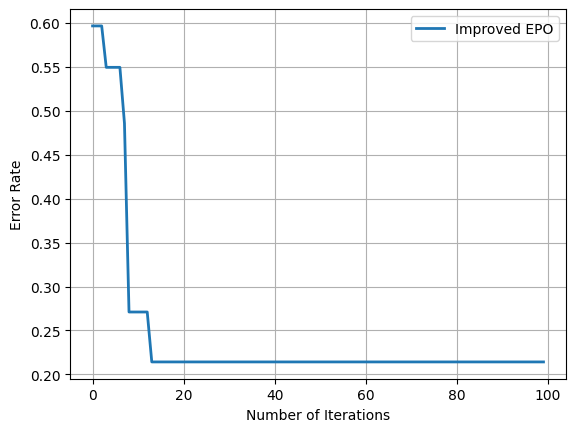

In [ ]:

import numpy as np
from scipy.special import gamma

# Function initialization
def initialization(SearchAgents_no, dim, ub, lb):
    if isinstance(ub, (float, int)):
        ub = np.ones(dim) * ub
        lb = np.ones(dim) * lb
    return np.random.rand(SearchAgents_no, dim) * (ub - lb) + lb

def Levy(d, damping=1):
    beta = 1.5
    sigma = (gamma(1 + beta) * np.sin(np.pi * beta / 2) /
             (gamma((1 + beta) / 2) * beta * 2 ** ((beta - 1) / 2))) ** (1 / beta)
    u = np.random.randn(d) * sigma
    v = np.random.randn(d)
    step = u / np.abs(v) ** (1 / beta)
    return step * damping
def smoothed_fitness(fitness_values, smoothing_factor=0.1):
    smoothed = (1 - smoothing_factor) * fitness_values + smoothing_factor * np.mean(fitness_values)
    return smoothed

def Get_Functions_details(F):
    if F == 'F1':
        fobj = F1
        lb = -1
        ub = 1
        dim = 5
    return lb, ub, dim, fobj

# Test Functions
def F1(x):
    return np.sum(x ** 2)

def PO_C_Improved(N, Max_iter, lb, ub, dim, fobj):
    if isinstance(ub, (float, int)):
        ub = np.ones(dim) * ub
        lb = np.ones(dim) * lb

    # Initialization
    X = initialization(N, dim, ub, lb)
    fitness = np.array([fobj(X[i, :]) for i in range(N)])
    best_fitness_idx = np.argmin(fitness)
    GBestX = X[best_fitness_idx, :]
    GBestF = fitness[best_fitness_idx]

    # Convergence tracking
    curve = np.zeros(Max_iter)
    alpha = 0.5  # Initial learning rate
    damping_factor = 0.9  # For controlling Levy flight

    for iteration in range(Max_iter):
        for i in range(N):
            St = np.random.randint(1, 6)
            if St == 1:
                X[i, :] += Levy(dim, damping=damping_factor) * (GBestX - X[i, :]) * alpha
            elif St == 2:
                X[i, :] += Levy(dim, damping=damping_factor) * GBestX
            elif St == 3 or St == 5:
                X[i, :] += alpha * (X[i, :] - np.mean(X, axis=0))
            else:
                X[i, :] += alpha * (GBestX - X[i, :])

            # Enforce boundaries
            X[i, :] = np.clip(X[i, :], lb, ub)

        # Fitness evaluation
        fitness = np.array([fobj(X[j, :]) for j in range(N)])

        # Smooth fitness for better stability
        fitness = smoothed_fitness(fitness)

        best_fitness_idx = np.argmin(fitness)
        if fitness[best_fitness_idx] < GBestF:
            GBestF = fitness[best_fitness_idx]
            GBestX = X[best_fitness_idx, :]

        # Record best fitness
        curve[iteration] = GBestF

        # Dynamic adjustment
        alpha *= 0.99  # Gradually reduce learning rate
        damping_factor *= 0.99  # Reduce Levy flight step size

        # Debugging output
        if iteration % 10 == 0:
            print(f"Iteration {iteration}, Best Fitness: {GBestF}")

    return curve, GBestX, GBestF

# Example usage
N = 10  # Number of search agents
Function_name = 'F1'  # Name of the test function (F1 to F23)
Max_iteration = 100  # Maximum number of iterations

lb, ub, dim, fobj = Get_Functions_details(Function_name)
# Example usage
curve, Best_pos, Best_score = PO_C_Improved(N, Max_iteration, lb, ub, dim, fobj)

# Plot convergence
import matplotlib.pyplot as plt
plt.plot(curve, label='Improved EPO', linewidth=2)
plt.xlabel('Number of Iterations')
plt.ylabel('Error Rate')
plt.legend()
plt.grid()
plt.show()


# 5. OELM for Classification

Epoch 1/200


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.5323 - loss: 0.6900 - val_accuracy: 0.4971 - val_loss: 0.6887
Epoch 2/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5057 - loss: 0.6866 - val_accuracy: 0.4980 - val_loss: 0.6842
Epoch 3/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5084 - loss: 0.6803 - val_accuracy: 0.5037 - val_loss: 0.6795
Epoch 4/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5056 - loss: 0.6780 - val_accuracy: 0.5649 - val_loss: 0.6744
Epoch 5/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5512 - loss: 0.6702 - val_accuracy: 0.5960 - val_loss: 0.6690
Epoch 6/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6082 - loss: 0.6663 - val_accuracy: 0.6254 - val_loss: 0.6630
Epoch 7/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6356 - loss: 0.6570 - val_accuracy: 0.7037 - val_loss: 0.6558
Epoch 8/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7298 - loss: 0.6468 - val_accuracy: 0.7754 - val_loss: 

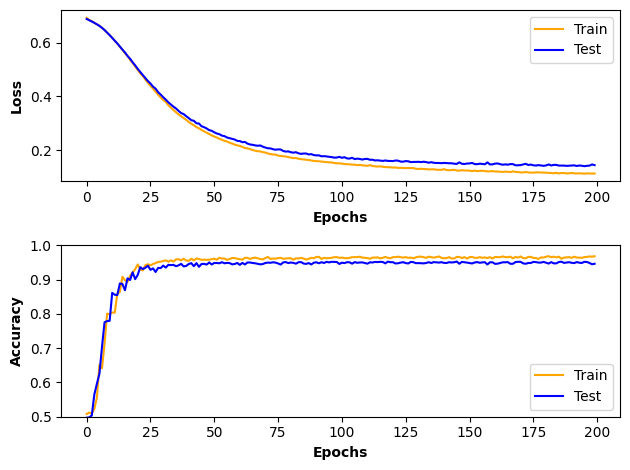

In [ ]:
num_epochs = 200
import OELM
from matplotlib import pyplot
X_train_selected, X_val_selected, Y_train, Y_val,train_indices,test_indices = train_test_split(sf, Y,np.arange(len(sf)), test_size=0.3, random_state=42)
# Train the ELM on the selected features
OELM_model = ELM(input_size=X_train_selected.shape[1], hidden_size=int(np.round(Best_score*1e2,0)))
OELM_model.fit(X_train_selected, Y_train)
history=OELM.model(X_train_selected, Y_train,num_epochs)
predicted_label=OELM.predict(X_val_selected,Y_val,0)

# Plot loss during training
pyplot.subplot(211)
pyplot.plot(history.history['loss'], label='Train', color='orange')
pyplot.plot(history.history['val_loss'], label='Test', color='blue')
pyplot.legend()
pyplot.xlabel('Epochs', fontweight='bold')
pyplot.ylabel('Loss', fontweight='bold')

# Plot accuracy during training
pyplot.subplot(212)
pyplot.plot(history.history['accuracy'], label='Train', color='orange')
pyplot.plot(history.history['val_accuracy'], label='Test', color='blue')
pyplot.legend()
pyplot.xlabel('Epochs', fontweight='bold')
pyplot.ylabel('Accuracy', fontweight='bold')
pyplot.ylim([0.5, 1])  # Set y-axis limit for accuracy (between 0 and 1)

# Show the plot
pyplot.tight_layout()
pyplot.show()

# Performances

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,cohen_kappa_score,matthews_corrcoef
from sklearn.metrics import precision_score, recall_score, f1_score,\
                            accuracy_score, balanced_accuracy_score,classification_report,\
                            ConfusionMatrixDisplay, confusion_matrix
import pandas as pd
import seaborn as sns # Import the seaborn library

def Eval_Metrices(y_test, ypred):
  print("Confusion Matrix","\n")
  score = round(accuracy_score(y_test, ypred),3)
  cm=confusion_matrix(y_test, ypred)
  cm1 = pd.DataFrame(cm , index = ['UnHealthy', 'Healthy'] , columns = ['UnHealthy', 'Healthy'])
  sensitivity1 = cm[0,0]/(cm[0,0]+cm[0,1])
  specificity1 = cm[1,1]/(cm[1,0]+cm[1,1])
  sns.heatmap(cm1, annot=True, fmt=".1f", linewidths=.3,
        square = True, cmap = 'Purples')
  plt.ylabel('Actual label',fontsize=15)
  plt.xlabel('Predicted label',fontsize=15)
  plt.title('Accuracy Score: {0}'.format(score), size = 13)
  plt.show()
  print("\n")
  print(classification_report(y_test,ypred))
  mae = mean_absolute_error(y_test, ypred)
  mse = mean_squared_error(y_test, ypred)
  rmse = np.sqrt(mse)
  precision = precision_score(y_test, ypred, pos_label=1)
  print('Mean Absolute Error (MAE): %.2f' % mae)
  print('Mean Squared Error (MSE): %.2f' % mse)
  print('Root Mean Squared Error (RMSE): %.2f' % rmse)
  print("Cohen Score",cohen_kappa_score(y_test, ypred))
  print('Precision: ' , precision)
  print("Matthew Score",matthews_corrcoef(y_test, ypred))
  print('Sensitivity : ', sensitivity1 )
  print('Specificity : ', specificity1)


Confusion Matrix 



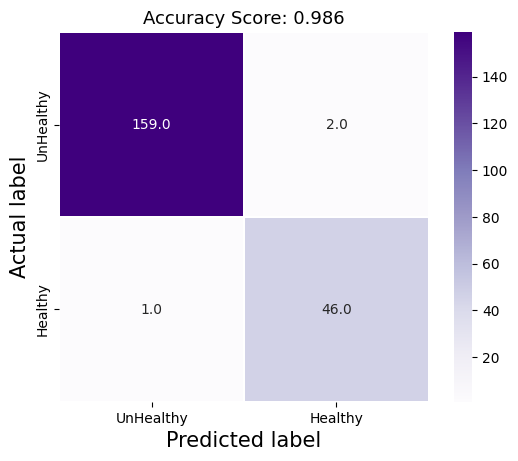



              precision    recall  f1-score   support

           0       0.99      0.99      0.99       161
           1       0.96      0.98      0.97        47

    accuracy                           0.99       208
   macro avg       0.98      0.98      0.98       208
weighted avg       0.99      0.99      0.99       208

Mean Absolute Error (MAE): 0.01
Mean Squared Error (MSE): 0.01
Root Mean Squared Error (RMSE): 0.12
Cohen Score 0.9590766002098636
Precision:  0.9583333333333334
Matthew Score 0.9591658453998155
Sensitivity :  0.9875776397515528
Specificity :  0.9787234042553191


In [ ]:
Eval_Metrices(Y_val, predicted_label)

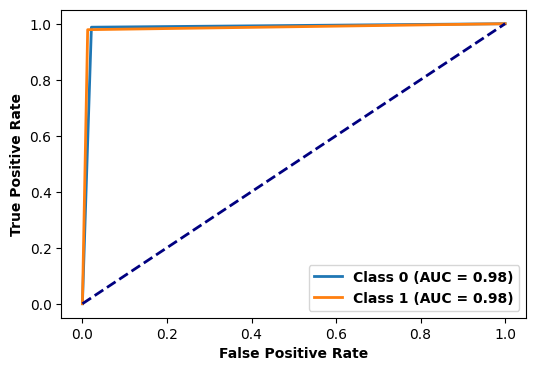

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import OneHotEncoder

# Convert predicted labels and true labels to numpy arrays
predict = np.array(predicted_label)
y_test = np.array(Y_val)

# Ensure predicted labels are in the same shape as true labels
predict = predict.reshape(-1, 1)

# One-hot encode both y_test and predicted labels
onehotencoder = OneHotEncoder(sparse_output=False)  # Updated parameter for new versions of sklearn
y_test_bin = onehotencoder.fit_transform(y_test.reshape(-1, 1))
ypred_bin = onehotencoder.transform(predict)

# Number of classes
n_classes = y_test_bin.shape[1]

# Initialize variables to store fpr, tpr, and auc for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

# Calculate ROC curve and AUC for each class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], ypred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
plt.figure(figsize=(6, 4))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.legend(loc='lower right', prop={'weight': 'bold'})

plt.show()


# Actual Vs Predicted output

Originally:  huntington
Predicted:  huntington


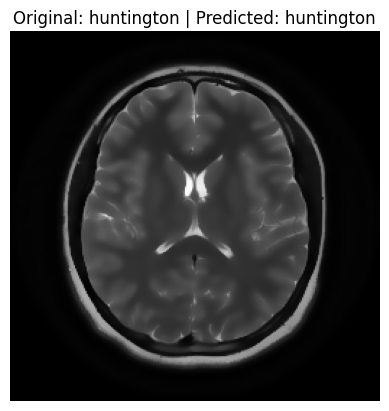

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import array_to_img

test_index = np.random.randint(len(test_indices))


# Find the index of the corresponding image in all_img using test_indices
corresponding_img_index = test_indices[test_index]

# Retrieve the original and predicted labels
original_label = all_labels[np.argmax(y_test[test_index])]
predicted_label = all_labels[np.argmax(predicted_label[test_index])]

# Print the results
print("Originally: ", original_label)
print("Predicted: ", predicted_label)

# Display the corresponding image from all_img
img_from_test_set = all_img[corresponding_img_index]

# Convert to image format
img = array_to_img(img_from_test_set)

# Display the image using matplotlib
plt.imshow(img)
plt.title(f"Original: {original_label} | Predicted: {predicted_label}")
plt.axis('off')
plt.show()


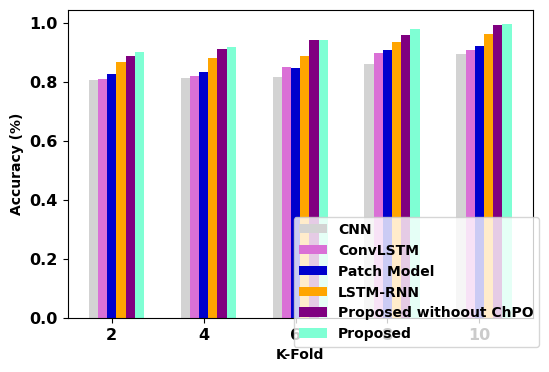

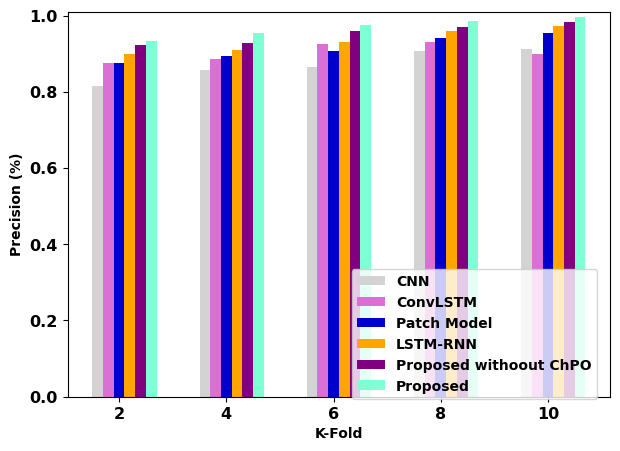

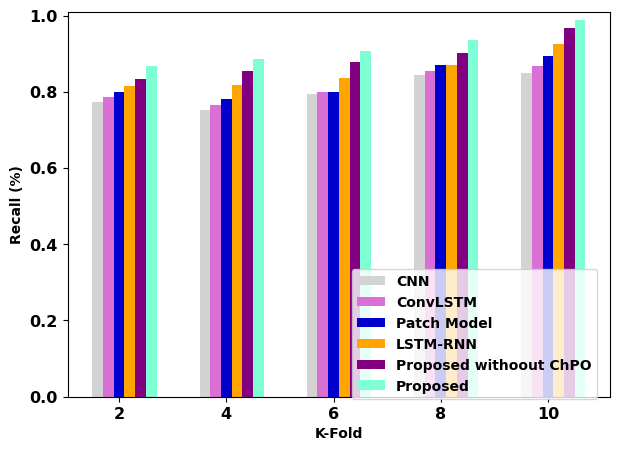

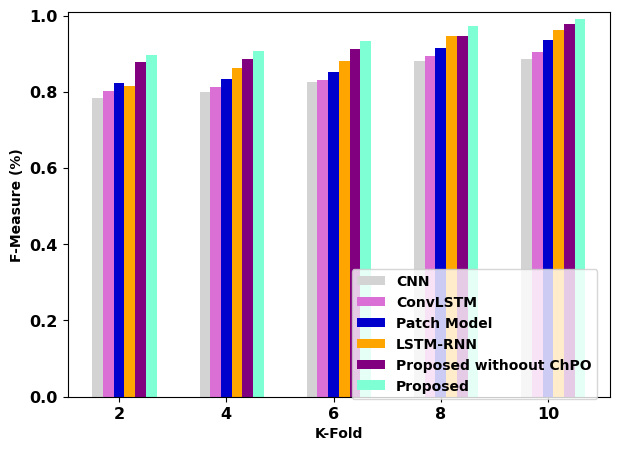

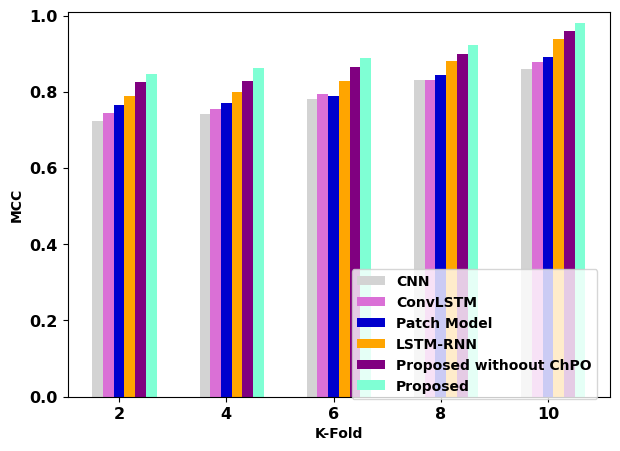

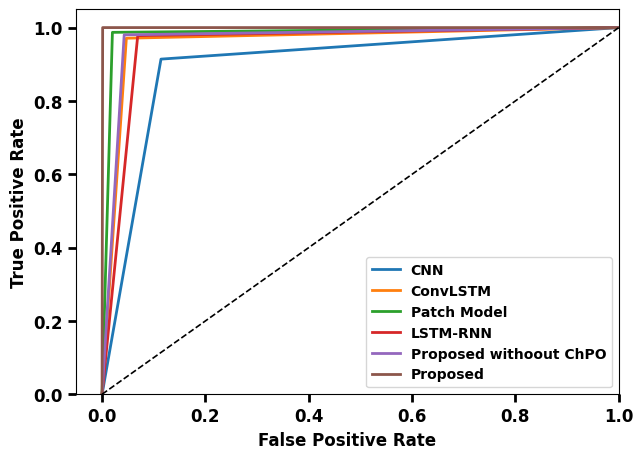

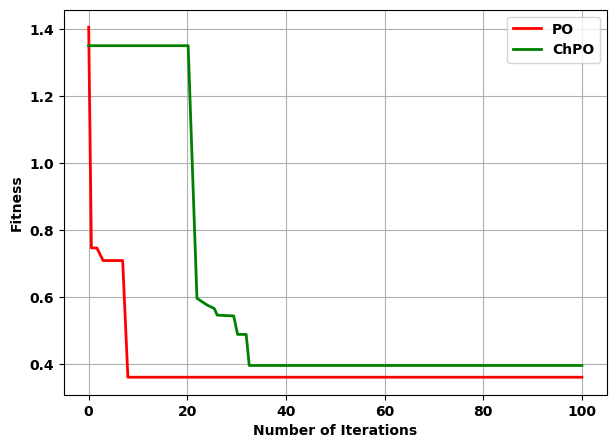

In [ ]:
import comparison  # Assuming the file is named comparison.py
m=comparison.perform()